In [1]:
import ctypes as ct
import MDAnalysis as mda
import MDA_unwrap_PBC as unwrap
from scipy.fft import fft, ifft, dct, idct
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
# ctype data structures for rotatable bonds
class t_rotBond(ct.Structure):
    '''datatype describing a rotatable bonds and its satellites'''
    _fields_ = (("bondAtomIndices", ct.c_int32*2),
                ("sat0AtomIndices", ct.c_int32*4),
                ("nSat0", ct.c_int32),
                ("sat3AtomIndices", ct.c_int32*4),
                ("nSat3", ct.c_int32),
                ("inertiaBuffer", ct.POINTER(ct.c_float)),
                ("angMomBuffer", ct.POINTER(ct.c_float)))

class t_rotBondSet(ct.Structure):
    '''datatype describing a list of rotatable bonds (e.g., for a single residue)'''
    _fields_ = (("rotBonds", ct.POINTER(t_rotBond)),
                ("nRotBonds", ct.c_int32))

class t_rotBondSets(ct.Structure):
    '''datatype describing a list of rotatable bond sets (e.g., for each residue in a selection)'''
    _fields_ = (("rotBondSets", ct.POINTER(t_rotBondSet)),
                ("nRotBondSets", ct.c_int32))

In [3]:
#load the shared library with C routines
clib = ct.cdll.LoadLibrary("vdos.so")

In [4]:
#define argument types of function 'inertiaTensorAngularMomentumLabFrame' in imported library 'clib'
clib.inertiaTensorAngularMomentumLabFrame.argtypes = [
    #number of atoms of one residue
    ct.c_int32,
    #list of masses in one residue
    np.ctypeslib.ndpointer(dtype=np.float64, ndim=2, flags='C_CONTIGUOUS'),
    #atomic coordinates of one residue
    np.ctypeslib.ndpointer(dtype=np.float64, ndim=2, flags='C_CONTIGUOUS'),
    #atomic velocities of one residue
    np.ctypeslib.ndpointer(dtype=np.float64, ndim=2, flags='C_CONTIGUOUS'),
    #inertia Tensor of one residue
    np.ctypeslib.ndpointer(dtype=np.float64, ndim=2, flags='C_CONTIGUOUS'),
    #angular momentum of one residue
    np.ctypeslib.ndpointer(dtype=np.float64, ndim=1, flags='C_CONTIGUOUS')
]
#define return type of function 'inertiaTensorAngularMomentumLabFrame' in imported library 'clib'
clib.inertiaTensorAngularMomentumLabFrame.restype = ct.c_int32

#define argument types of function 'applyAxes' in imported library 'clib'
clib.applyAxes.argtypes = [
    #list of moments of inertia, e.g., eigenvalues of inertia tensor
    np.ctypeslib.ndpointer(dtype=np.float64, ndim=1, flags='C_CONTIGUOUS'),
    #list of rotational axes (transposed rmatrix), e.g., eigenvectors of inertia tensor
    np.ctypeslib.ndpointer(dtype=np.float64, ndim=2, flags='C_CONTIGUOUS'),
    #angular momentum in lab frame
    np.ctypeslib.ndpointer(dtype=np.float64, ndim=1, flags='C_CONTIGUOUS'),
    #angular momentum in molecular frame (to be computed)
    np.ctypeslib.ndpointer(dtype=np.float64, ndim=1, flags='C_CONTIGUOUS'),
    #number of atoms of one residue
    ct.c_int32,
    #atomic coordinates of one residue
    np.ctypeslib.ndpointer(dtype=np.float64, ndim=2, flags='C_CONTIGUOUS'),
    #atomic velocities of one residue
    np.ctypeslib.ndpointer(dtype=np.float64, ndim=2, flags='C_CONTIGUOUS')
]
#define return type of function 'applyAxes' in imported library 'clib'
clib.applyAxes.restype = ct.c_int32

#define argument types of function 'getRotBonds' in imported library 'clib'
clib.getRotBonds.argtypes = [
    #sets of rotatable bonds for each residue
    ct.POINTER(t_rotBondSets),
    #number of residues
    ct.c_int32,
    #list of atom indices for dihedrals
    np.ctypeslib.ndpointer(dtype=np.int32, ndim=2, flags='C_CONTIGUOUS'),
    #number of dihedrals
    ct.c_int32,
    #pair of atom indices indicating the first and last atom index of each residue
    np.ctypeslib.ndpointer(dtype=np.int32, ndim=2, flags='C_CONTIGUOUS'),
    #number of correlation times to allocate arrays
    ct.c_int32
]
#define return type of function 'getRotBonds' in imported library 'clib'
clib.getRotBonds.restype = ct.c_int32

#define argument types of function 'analyzeRotBondsInResidue' in imported library 'clib'
clib.analyzeRotBondsInResidue.argtypes = [
    #set of rotatable bonds for one residue
    ct.POINTER(t_rotBondSet),
    #list of atom masses in residue
    np.ctypeslib.ndpointer(dtype=np.float64, ndim=2, flags='C_CONTIGUOUS'),
    #list of atom positions in residue
    np.ctypeslib.ndpointer(dtype=np.float64, ndim=2, flags='C_CONTIGUOUS'),
    #list of atom velocities in residue
    np.ctypeslib.ndpointer(dtype=np.float64, ndim=2, flags='C_CONTIGUOUS'),
    #time step
    ct.c_int32,
    #number of correlation times
    ct.c_int32
]
#define return type of function 'analyzeRotBondsInResidue' in imported library 'clib'
clib.analyzeRotBondsInResidue.restype = ct.c_int32

#define argument types of function 'corrRotBonds' in imported library 'clib'
clib.corrRotBonds.argtypes = [
    #sets of rotatable bonds for each residue
    ct.POINTER(t_rotBondSets),
    #array of correlation functions for each residue
    np.ctypeslib.ndpointer(dtype=np.float64, ndim=2, flags='C_CONTIGUOUS'),
    #start, i.e., index of reference time in circular array
    ct.c_int32,
    #number of correlation times
    ct.c_int32
]
#define return type of function 'corrRotBonds' in imported library 'clib'
clib.corrRotBonds.restype = ct.c_int32

#define argument types of function 'corrAtomsRes' in imported library 'clib'
clib.corrAtomsRes.argtypes = [
    #number of atoms in residue
    ct.c_int32,
    #residue index
    ct.c_int32,
    #number of residues
    ct.c_int32,
    #array of atomic massed for one residue
    np.ctypeslib.ndpointer(dtype=np.float64, ndim=2, flags='C_CONTIGUOUS'),
    #circular buffer of atomic velocites for one resiude
    np.ctypeslib.ndpointer(dtype=np.float64, ndim=3, flags='C_CONTIGUOUS'),
    #array for correlation function for one residue
    np.ctypeslib.ndpointer(dtype=np.float64, ndim=2, flags='C_CONTIGUOUS'),
    #start, i.e., index of reference time in circular array
    ct.c_int32,
    #number of correlation times
    ct.c_int32
]
#define return type of function 'corrAtomsRes' in imported library 'clib'
clib.corrAtomsRes.restype = ct.c_int32

In [5]:
 class vdos:
    def __init__(self,sel,nCorr):
        self.sel = sel
        self.nCorr = nCorr
        self.nRes = sel.residues.n_residues
        # initialize lists and arrays
        #
        #Note: atMassLists & atVelBuffers are lists of numpy arrays
        #      => they are not a numpy arrays themselves
        self.atMassLists = [] # list of numpy arrays of atomic masses for each residue
        self.atVelBuffers = [] # list of numpy array buffers of atomic velocities for each residue
        for res in self.sel.residues:
            #Note: np.newaxis is used to make the array 2D
            self.atMassLists.append(res.atoms.masses[:,np.newaxis].astype('float64'))
            self.atVelBuffers.append(np.zeros((nCorr, len(res.atoms), 3), dtype = np.float64))
        # numpy array of residue masses from MDAnalysis
        self.resMassList = sel.residues.masses
        # numpy array buffers for COM position, COM velocity, angular momentum, and (sorted) moments of inertia
        self.COMposBuffer = np.zeros((nCorr, self.nRes, 3), dtype = np.float64)
        self.COMvelBuffer = np.zeros((nCorr, self.nRes, 3), dtype = np.float64)
        self.angMomBuffer = np.zeros((nCorr, self.nRes, 3), dtype = np.float64)
        self.inertiaBuffer = np.zeros((nCorr, self.nRes, 3), dtype = np.float64)
        # time and frequency axes for correlation functions and VDoS
        self.tau = np.zeros(nCorr, dtype = np.float64)
        self.wavenumber = np.zeros(nCorr, dtype = np.float64)
        # numpy arrays for correlation functions and VDoS
        # -> rigid body translation
        self.trCorr = np.zeros((nCorr, self.nRes), dtype = np.float64)
        self.trVDoS = np.zeros((nCorr, self.nRes), dtype = np.float64)
        # -> rigid body rotation
        self.rotCorr = np.zeros((nCorr, self.nRes), dtype = np.float64)
        self.rotVDoS = np.zeros((nCorr, self.nRes), dtype = np.float64)
        # -> rotatable bonds
        self.rotBondCorr = np.zeros((nCorr, self.nRes), dtype = np.float64)
        self.rotBondVDoS = np.zeros((nCorr, self.nRes), dtype = np.float64)
        # -> total VDoS
        self.totalCorr = np.zeros((nCorr, self.nRes), dtype = np.float64)
        self.totalVDoS = np.zeros((nCorr, self.nRes), dtype = np.float64)
        # initialize counter for normalization
        self.corrCnt = np.zeros(self.nRes, dtype = int)
        # flag for normalization
        self.normalized = 0
        # initialize rotatable bonds for selection (see definition of getRotBonds)
        self.rotBondSets = self.getRotBonds()
        
    def processStep(self,tStep,time):
        '''process a single time step of the simulation'''
        idx = tStep % self.nCorr
        if tStep < self.nCorr:
            self.tau[tStep] = time
        pos = []
        vel = []
        r = 0
        #compute center of mass position and velocity
        for res in self.sel.residues:
            pos.append(res.atoms.positions.astype('float64'))
            vel.append(res.atoms.velocities.astype('float64'))
            #store all atomic velocities for current residue in buffer for total corr and VDoS
            self.atVelBuffers[r][idx] = vel[-1]
            #self.COMposBuffer[idx,r] = res.atoms.center_of_mass() # => too slow & no equivalent for velocity
            self.COMposBuffer[idx,r] = np.sum(self.atMassLists[r] * pos[-1] , axis = 0) / self.resMassList[r]
            self.COMvelBuffer[idx,r] = np.sum(self.atMassLists[r] * vel[-1], axis = 0) / self.resMassList[r]
            r += 1
        r = 0
        #remove center of mass position and velocity before computing angular momentum
        for res in self.sel.residues:
            pos[r] = pos[r] - self.COMposBuffer[idx,r]
            vel[r] = vel[r] - self.COMvelBuffer[idx,r]
            r += 1
        #compute angular momentum and inertia tensor
        #automatically removes rigid body rotation from velocities
        self.angMomBuffer[idx], self.inertiaBuffer[idx] = self.angMomInfo(pos,vel)
        #compute correlation functions for rotatable bonds
        for r in range(self.nRes):
            error = clib.analyzeRotBondsInResidue(
                ct.pointer(self.rotBondSets.rotBondSets[r]),
                self.atMassLists[r],
                pos[r],
                vel[r],
                tStep,
                self.nCorr
            )
        #if sufficient data is available in buffers, compute correlation functions
        if tStep >= self.nCorr - 1:
            self.calcCorr(tStep+1)
            
    def calcCorr(self,start):
        '''compute correlation functions for all data in buffers'''
        #compute time correlation function for COM translation and rotation (for each residue)
        for i in range(self.nCorr):
            j = start % self.nCorr
            k = (j + i) % self.nCorr
            self.trCorr[i] += np.sum(self.COMvelBuffer[j] * self.COMvelBuffer[k], axis = 1)
            self.rotCorr[i] += np.sum(self.angMomBuffer[j] * self.angMomBuffer[k] / np.sqrt(self.inertiaBuffer[j] * self.inertiaBuffer[k]), axis = 1).real
        #compute time correlation function for rotatable bonds (for each residue, averged over rotatable bonds)
        error = clib.corrRotBonds(
            ct.pointer(self.rotBondSets),
            self.rotBondCorr,
            start,
            self.nCorr)
        #compute time correlation function for all atoms (for each residue, averaged over atoms)
        #for i in range(self.nCorr):
            # j = start % self.nCorr
            # k = (j + i) % self.nCorr
            # for r in range(self.nRes):
            #     self.totalCorr[i][r] += np.sum(self.atMassLists[r] * self.atVelBuffers[r][j] * self.atVelBuffers[r][k])
        for r in range(self.nRes):
            error = clib.corrAtomsRes(
                len(self.atMassLists[r]),
                r,
                self.nRes,
                self.atMassLists[r],
                self.atVelBuffers[r],
                self.totalCorr,
                start,
                self.nCorr
            )
        self.corrCnt += 1

    def normalize(self):
        '''normalize correlation functions by number of data points'''
        if self.normalized == 0:
            for i in range(self.nRes):
                self.trCorr[:,i] *= self.resMassList[i] / self.corrCnt[i]
                self.rotCorr[:,i] /= self.corrCnt[i]
                self.rotBondCorr[:,i] /= self.corrCnt[i]
                self.totalCorr[:,i] /= self.corrCnt[i]
            self.normalized = 1
    
    def calcVDOS(self):
        '''compute vibrational density of states from time correlation functions'''
        period = (self.tau[1] - self.tau[0]) * (2 * self.nCorr - 1)
        wn0 = (1.0 / period) * 33.35641
        self.wavenumber = np.arange(0,self.nCorr) * wn0
        tmp1 = np.zeros(2 * self.nCorr - 1, dtype = np.float64)
        tmp2 = np.zeros(2 * self.nCorr - 1, dtype = np.float64)
        tmp3 = np.zeros(2 * self.nCorr - 1, dtype = np.float64)
        tmp4 = np.zeros(2 * self.nCorr - 1, dtype = np.float64)
        for i in range(self.nRes):
            for j in range(self.nCorr):
                tmp1[j] = self.trCorr[j][i]
                tmp2[j] = self.rotCorr[j][i]
                tmp3[j] = self.rotBondCorr[j][i]
                tmp4[j] = self.totalCorr[j][i]
            for j in range(1,self.nCorr):
                k = 2 * self.nCorr - j - 1
                tmp1[k] = tmp1[j]
                tmp2[k] = tmp2[j]
                tmp3[k] = tmp3[j]
                tmp4[k] = tmp4[j]
            tmp1 = fft(tmp1)
            tmp2 = fft(tmp2)
            tmp3 = fft(tmp3)
            tmp4 = fft(tmp4)
            for j in range(self.nCorr):
                self.trVDoS[j][i] = tmp1[j].real / np.sqrt(2 * self.nCorr - 1)
                self.rotVDoS[j][i] = tmp2[j].real / np.sqrt(2 * self.nCorr - 1)
                self.rotBondVDoS[j][i] = tmp3[j].real / np.sqrt(2 * self.nCorr - 1)
                self.totalVDoS[j][i] = tmp4[j].real / np.sqrt(2 * self.nCorr - 1)

    # def inertiaTensor(self,pos):
    #     '''compute inertia tensor for each residue in selection'''
    #     I = np.zeros((self.nRes,3,3), dtype = np.float64)
    #     for r in range(self.nRes):
    #         masses = (self.atMassLists[r])[:,0]
    #         crd = (pos[r])
    #         I[r,0,0] = np.sum(masses * (crd[:,1]**2 + crd[:,2]**2))
    #         I[r,1,1] = np.sum(masses * (crd[:,0]**2 + crd[:,2]**2))
    #         I[r,2,2] = np.sum(masses * (crd[:,0]**2 + crd[:,1]**2))
    #         I[r,0,1] = -np.sum(masses * crd[:,0] * crd[:,1])
    #         I[r,0,2] = -np.sum(masses * crd[:,0] * crd[:,2])
    #         I[r,1,2] = -np.sum(masses * crd[:,1] * crd[:,2])
    #         I[r,1,0] = I[r,0,1]
    #         I[r,2,0] = I[r,0,2]
    #         I[r,2,1] = I[r,1,2]
    #     return I

    # def angMomLabFrame(self,pos,vel):
    #     '''compute angular momentum for each residue in selection'''
    #     #Note: atMassLists is a list of numpy arrays
    #     #      => atMassLists itself is not a numpy array
    #     #Note: pos and vel are lists of numpy arrays
    #     #      => pos and vel themselves are not numpy arrays
    #     #Note: center of mass coordinates are expected to have been substracted from pos
    #     #Note: center of mass velocities are expected to have been substracted from vel
    #     L = np.zeros((self.nRes,3), dtype = np.float64)
    #     for r in range(self.nRes):
    #         L[r] += np.sum(self.atMassLists[r] * np.cross(pos[r],vel[r]), axis = 0)
    #     return L

    # def rotAxes(self,I):
    #     '''compute principal axes of rotation for a given inertia tensor'''
    #     evals,evecsTmp = np.linalg.eig(I)
    #     #sort eigenvalues and eigenvectors
    #     #Purpose: ordering of the rotational axis needs to be consistent between time steps for correlation functions
    #     #Question: --> is this necessary or is the ordering of generated eigenvalues consistent???
    #     #              e.g., small to large eigenvalues: need to check docs for np.linalg.eig
    #     idx = evals.argsort()[::-1]   
    #     evals = evals[idx]
    #     evecsTmp = evecsTmp[:,idx]
    #     evecs = np.zeros((3,3), dtype = np.float64)
    #     evecs[0] = evecsTmp[0]
    #     evecs[1] = evecsTmp[1]
    #     evecs[2] = evecsTmp[2]
    #     return evals, evecs

    def rotAxes(self,I):
        '''compute principal axes of rotation for a given inertia tensor'''
        #use this version for python implementation of clib.applyAxes
        evals,evecs = np.linalg.eig(I)
        #sort eigenvalues and eigenvectors
        #Purpose: ordering of the rotational axis needs to be consistent between time steps for correlation functions
        #Question: --> is this necessary or is the ordering of generated eigenvalues consistent???
        #              e.g., small to large eigenvalues: need to check docs for np.linalg.eig
        idx = evals.argsort()[::-1]   
        evals = evals[idx]
        evecs = evecs[:,idx]
        # #use this version for C implementation of clib.applyAxes
        # evals,evecsTmp = np.linalg.eig(I)
        # #sort eigenvalues and eigenvectors
        # #Purpose: ordering of the rotational axis needs to be consistent between time steps for correlation functions
        # #Question: --> is this necessary or is the ordering of generated eigenvalues consistent???
        # #              e.g., small to large eigenvalues: need to check docs for np.linalg.eig
        # idx = evals.argsort()[::-1]   
        # evecsTmp = evecsTmp[:,idx]
        # evecs = np.zeros((3,3), dtype = np.float64)
        # evecs[0] = evecsTmp[0]
        # evecs[1] = evecsTmp[1]
        # evecs[2] = evecsTmp[2]
        return evals, evecs

    def angMomMolFrame(self,L,evecs):
        '''rotate moment of inertia into molecular frame (defined by principal axes of rotation, i.e., evecs of inertia tensor)'''
        return np.dot(evecs.T,L)

    def omegaToLabFrame(self,omegaMol,evecs):
        '''rotate rotational velocity back into lab frame'''
        return np.dot(evecs,omegaMol)

    def angMomInfo(self,pos,vel):
        '''compute angular momentum and moments of inertia in molecular frame for each residue in selection'''
        # I = self.inertiaTensor(pos)
        # L = self.angMomLabFrame(pos,vel)
        I = np.zeros((self.nRes,3,3), dtype = np.float64)
        L = np.zeros((self.nRes,3), dtype = np.float64)
        r = 0
        for res in self.sel.residues:
            error = clib.inertiaTensorAngularMomentumLabFrame(
                len(res.atoms),
                self.atMassLists[r],
                pos[r],
                vel[r],
                I[r],
                L[r]
            )
            r += 1
        Lmol = np.zeros((self.nRes,3), dtype = np.float64)
        inertia = np.zeros((self.nRes,3), dtype = np.float64)
        for r in range(self.nRes):
            #eigenvalus are moments of inertia in molecular frame
            inertia[r],evecs = self.rotAxes(I[r])
            #C implementation requires changes in self.rotAxes and is slower
            # error = clib.applyAxes(inertia[r],evecs,L[r],Lmol[r],len(res.atoms),pos[r],vel[r])
            #BEGIN section that can be replaced by clib.applyAxes
            #rotate angular momentum to molecular frame
            Lmol[r] = self.angMomMolFrame(L[r],evecs)
            #rotational velocity in radians: omega = L/I
            omegaMol = Lmol[r] / inertia[r]
            #rotate
            omegaLab = self.omegaToLabFrame(omegaMol,evecs)
            #subtract rigid body rotation from velocities
            vel[r] -= np.cross(omegaLab,pos[r])
            #END section that can be replaced by clib.applyAxes
            # # if np.any(evals <= 0.0):
            # #     print("Error: non-positive eigenvalue in inertia tensor")
            # #     print("Eigenvalues: ",evals)
            # # if np.any(isinstance(evals,complex)):
            # #     print("Error: complex eigenvalue in inertia tensor")
            # #     print("Eigenvalues: ",evals)
        return Lmol, inertia

    def getRotBonds(self):
        '''construct list of rotatable bonds for selection'''
        dihed = self.sel.intra_dihedrals.indices
        resAtomRangeList = np.zeros((len(self.sel.residues),2), dtype = np.int32)
        i = 0
        for res in self.sel.residues:
            resAtomRangeList[i][0] = np.amin(res.atoms.indices)
            resAtomRangeList[i][1] = np.amax(res.atoms.indices)
            i += 1
        rotBondSets = t_rotBondSets()
        error = clib.getRotBonds(
            ct.pointer(rotBondSets),
            ct.c_int(len(self.sel.residues)),
            dihed,
            ct.c_int(len(dihed)),
            resAtomRangeList,
            self.nCorr
        )
        if error != 0:
            print(f'ERROR reported by \'getRotBonds\' function\n')
        return rotBondSets

In [6]:
TOPOL = "/Users/mheyden/Dropbox (ASU)/ASU-Research/POPC/run-NVE.tpr"
TRAJ = "/Users/mheyden/Dropbox (ASU)/ASU-Research/POPC/run-NVE_test.trr"
u = mda.Universe(TOPOL,TRAJ)
trees = unwrap.unwrap.buildTrees(u)
sel = u.select_atoms("resname POPC")
vdos = vdos(sel,200)

building intra-molecular bond trees ...
 -> detected 8016 molecules
 -> tree building time: 1.02s
 -> ready to unwrap


In [7]:
tmp = u.select_atoms("resid 1")
print(len(tmp.atoms))
print(len(tmp.bonds))
print(vdos.rotBondSets.rotBondSets[0].nRotBonds)

134
133
47


In [8]:
# print(vdos.rotBondSets.nRotBondSets)
# print(vdos.rotBondSets.rotBondSets[0].nRotBonds)
# print(vdos.rotBondSets.rotBondSets[127].nRotBonds)

In [9]:
# r = 1
# for i in range(vdos.rotBondSets.rotBondSets[r].nRotBonds):
#     print(f'rotatable bond #{i+1}')
#     print(vdos.rotBondSets.rotBondSets[r].rotBonds[i].bondAtomIndices[:])
#     n=vdos.rotBondSets.rotBondSets[r].rotBonds[i].nSat0
#     print(vdos.rotBondSets.rotBondSets[r].rotBonds[i].sat0AtomIndices[:n])
#     print(n)
#     n=vdos.rotBondSets.rotBondSets[r].rotBonds[i].nSat3
#     print(vdos.rotBondSets.rotBondSets[r].rotBonds[i].sat3AtomIndices[:n])
#     print(n)

In [10]:
tStep = 0
for ts in tqdm(u.trajectory):
    u.trajectory.ts._pos = unwrap.unwrap.unwrap(u,trees)
    vdos.processStep(tStep,ts.time)
    tStep += 1

100%|██████████| 626/626 [00:52<00:00, 11.94it/s]


In [11]:
vdos.normalize()
vdos.calcVDOS()

738.4435133307943


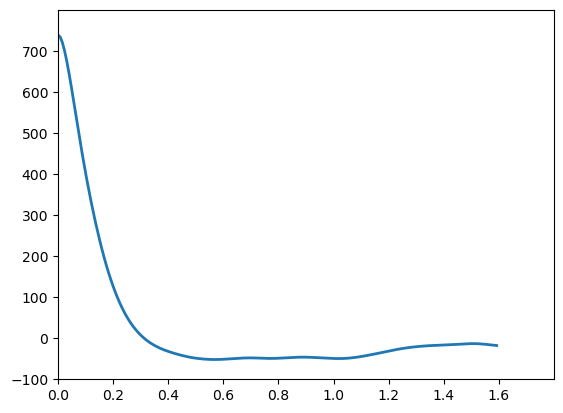

In [12]:
trFac = np.sum(vdos.trCorr, axis = 1)[0]
print(trFac/vdos.nRes)
# plot
fig, ax = plt.subplots()
ax.plot(vdos.tau, np.sum(vdos.trCorr, axis = 1) / vdos.nRes, linewidth = 2.0)
ax.set(xlim=(0, 1.8), xticks=np.arange(0,1.8,0.2),
       ylim=(-100, 800), yticks=np.arange(-100,800,100))
plt.show()

758.9776954720197


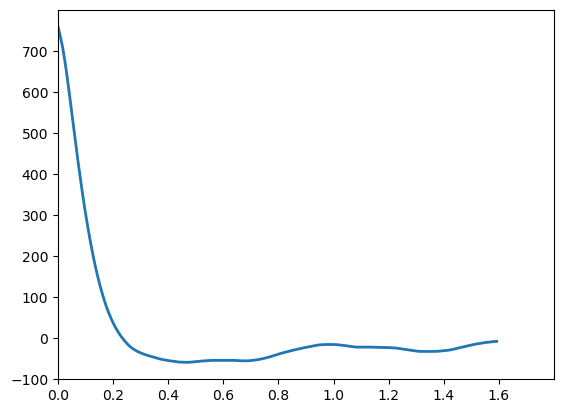

In [13]:
rotFac = np.sum(vdos.rotCorr, axis = 1)[0]
print(rotFac/vdos.nRes)
# plot
fig, ax = plt.subplots()
ax.plot(vdos.tau, np.sum(vdos.rotCorr, axis = 1) / vdos.nRes, linewidth = 2.0)
ax.set(xlim=(0, 1.8), xticks=np.arange(0,1.8,0.2),
       ylim=(-100, 800), yticks=np.arange(-100,800,100))
plt.show()

567.4426512307666


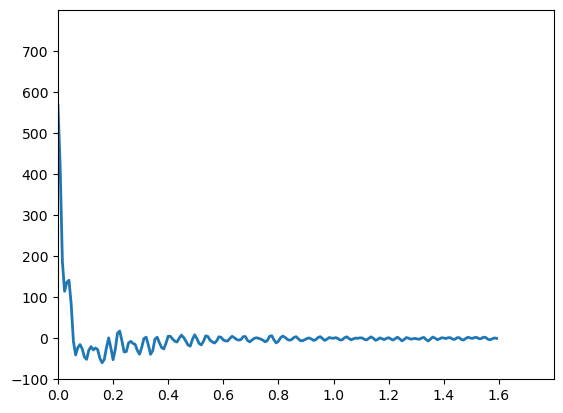

In [14]:
rotBondFac = np.sum(vdos.rotBondCorr, axis = 1)[0]
print(rotBondFac/vdos.nRes/47*3)
# plot
fig, ax = plt.subplots()
ax.plot(vdos.tau, np.sum(vdos.rotBondCorr, axis = 1) * 3 / (vdos.nRes*vdos.rotBondSets.rotBondSets[0].nRotBonds), linewidth = 2.0)
ax.set(xlim=(0, 1.8), xticks=np.arange(0,1.8,0.2),
       ylim=(-100, 800), yticks=np.arange(-100,800,100))
plt.show()

499.39672264648715


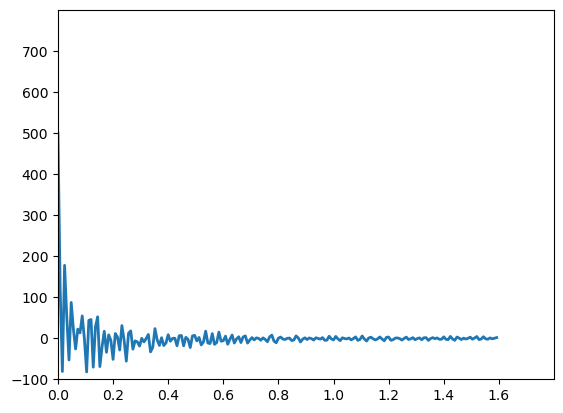

In [15]:
totalFac = np.sum(vdos.totalCorr, axis = 1)[0]
print(totalFac/vdos.nRes/134)
# plot
fig, ax = plt.subplots()
ax.plot(vdos.tau, np.sum(vdos.totalCorr, axis = 1) / (vdos.nRes*len(vdos.sel.residues[0].atoms)), linewidth = 2.0)
ax.set(xlim=(0, 1.8), xticks=np.arange(0,1.8,0.2),
       ylim=(-100, 800), yticks=np.arange(-100,800,100))
plt.show()

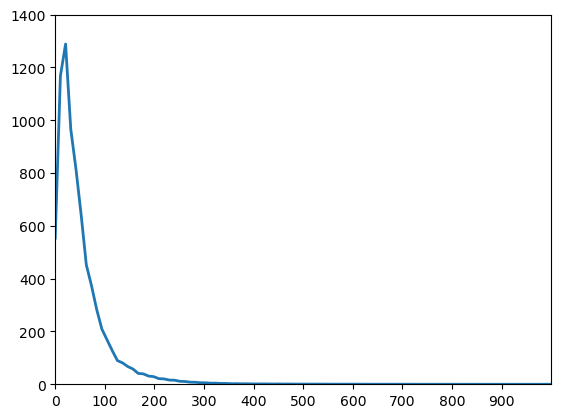

In [16]:
# plot
fig, ax = plt.subplots()
ax.plot(vdos.wavenumber, np.sum(vdos.trVDoS, axis = 1) / vdos.nRes, linewidth = 2.0)
ax.set(xlim=(0, 1000), xticks=np.arange(0,1000,100),
       ylim=(0, 1400.0), yticks=np.arange(0,1500,200))
plt.show()

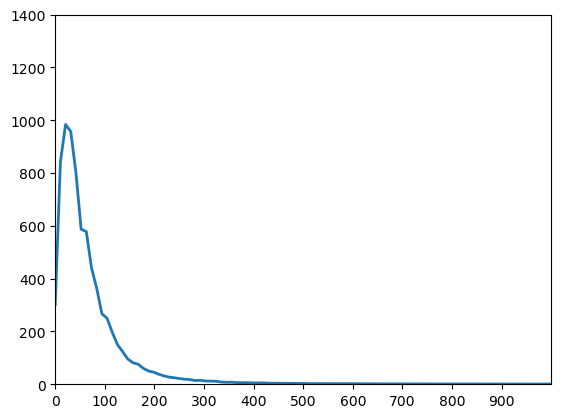

In [17]:
# plot
fig, ax = plt.subplots()
ax.plot(vdos.wavenumber, np.sum(vdos.rotVDoS, axis = 1) / vdos.nRes, linewidth = 2.0)
ax.set(xlim=(0, 1000), xticks=np.arange(0,1000,100),
       ylim=(0, 1400.0), yticks=np.arange(0,1500,200))
plt.show()

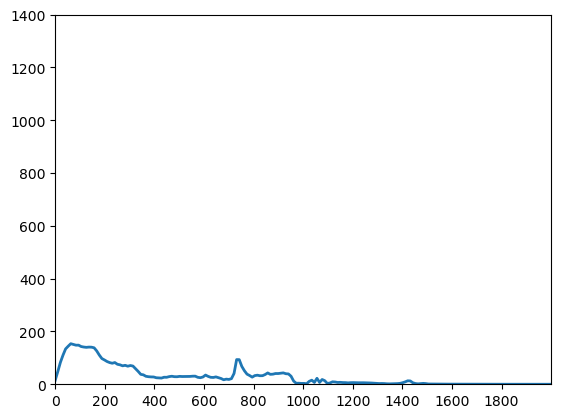

In [18]:
# plot
fig, ax = plt.subplots()
ax.plot(vdos.wavenumber, np.sum(vdos.rotBondVDoS, axis = 1) * 3 / (vdos.nRes*vdos.rotBondSets.rotBondSets[0].nRotBonds), linewidth = 2.0)
ax.set(xlim=(0, 2000), xticks=np.arange(0,2000,200),
       ylim=(0, 1400.0), yticks=np.arange(0,1500,200))
plt.show()

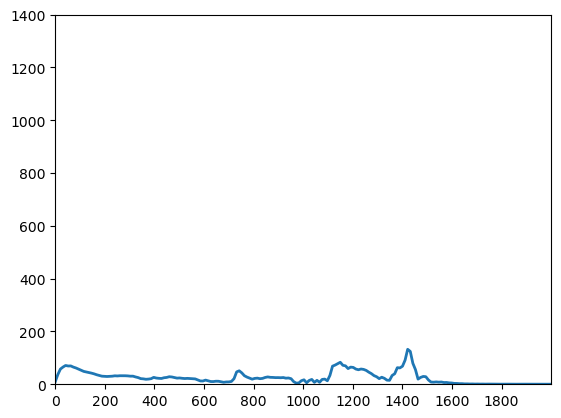

In [19]:
# plot
fig, ax = plt.subplots()
ax.plot(vdos.wavenumber, np.sum(vdos.totalVDoS, axis = 1) / (vdos.nRes*len(vdos.sel.residues[0].atoms)), linewidth = 2.0)
ax.set(xlim=(0, 2000), xticks=np.arange(0,2000,200),
       ylim=(0, 1400.0), yticks=np.arange(0,1500,200))
plt.show()

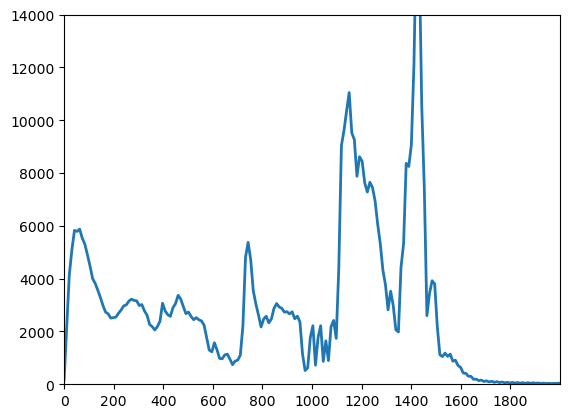

In [20]:
# plot
fig, ax = plt.subplots()
ax.plot(vdos.wavenumber, (np.sum(vdos.totalVDoS, axis = 1) - np.sum(vdos.rotBondVDoS, axis = 1) - np.sum(vdos.rotVDoS, axis = 1) - np.sum(vdos.trVDoS, axis = 1)) / vdos.nRes, linewidth = 2.0)
ax.set(xlim=(0, 2000), xticks=np.arange(0,2000,200),
       ylim=(0, 14000.0), yticks=np.arange(0,15000,2000))
plt.show()

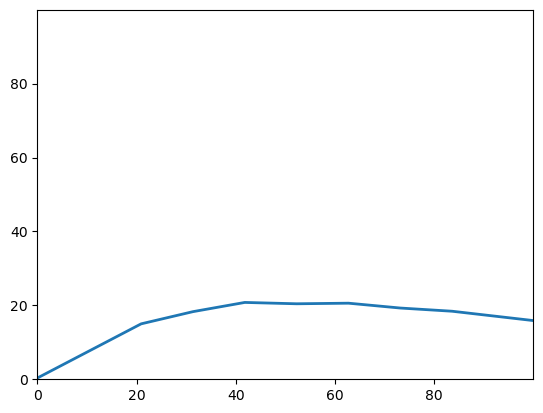

In [21]:
test = (134*3-133)*np.sum(vdos.totalVDoS, axis = 1)/totalFac - 47*np.sum(vdos.rotBondVDoS, axis = 1)/rotBondFac - 3*np.sum(vdos.rotVDoS, axis = 1)/rotFac - 3*np.sum(vdos.trVDoS, axis = 1)/trFac
# plot
fig, ax = plt.subplots()
ax.plot(vdos.wavenumber, test, linewidth = 2.0)
ax.set(xlim=(0, 100), xticks=np.arange(0,100,20),
       ylim=(0, 100.0), yticks=np.arange(0,100,20))
plt.show()

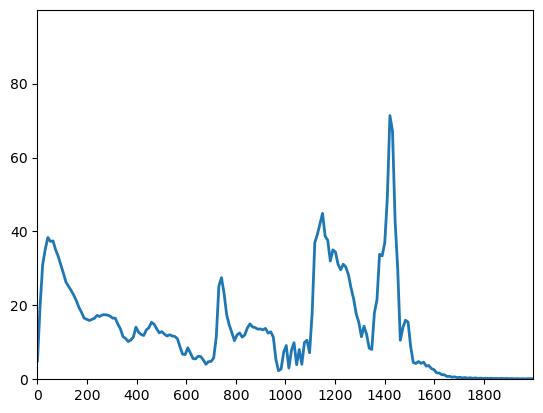

In [22]:
test = (134*3-133)*np.sum(vdos.totalVDoS, axis = 1)/totalFac
fig, ax = plt.subplots()
ax.plot(vdos.wavenumber, test, linewidth = 2.0)
ax.set(xlim=(0, 2000), xticks=np.arange(0,2000,200),
       ylim=(0, 100.0), yticks=np.arange(0,100,20))
plt.show()